In [1]:
import torch
import pandas as pd
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, fbeta_score, accuracy_score

In [2]:
# SET SEED FOR REPRODUCIBILITY
SEED = 150

In [3]:
# READ THE DATASET
df = pd.read_csv('diabetes.csv')

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# CHECK FOR NULL VALUES
# OBSERVING THE DATASET, THERE ARE NO NULL VALUES
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
# SUMMARY OF THE DATASET
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
# SINCE THE PERCEPTRON MODEL EXPECTS THE TARGET OUTPUTS TO BE +1 OR -1
# CONVERT ALL 0's IN THE 'Outcome' COLUMN TO -1
df.loc[df['Outcome'] == 0, 'Outcome'] = -1

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,-1
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,-1
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
# SCALER TO SCALE THE INPUT VALUES IN THE RANGE [-1,1]
scaler = MinMaxScaler(feature_range=(-1, 1))

In [8]:
# DROP THE 'Outcome' COLUMN AND THEN SCALE THE INPUT FEATURES
x = scaler.fit_transform(df.drop('Outcome', axis=1))
# GET THE OUTPUT VALUES
y = df['Outcome'].values

# SPLIT THE DATASET INTO TRAINING AND TEST SET
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15, stratify=y, random_state=SEED)

# CONVERT DATA TO PYTORCH TENSORS
x_train = torch.tensor(x_train, dtype=torch.float64)
x_test = torch.tensor(x_test, dtype=torch.float64)
y_train = torch.tensor(y_train, dtype=torch.float64)
y_test = torch.tensor(y_test, dtype=torch.float64)

**BASELINE MODEL**

In [9]:
# LEARNING-RATE / STEP-SIZE
lr = 0.1

# NO. OF ITERATIONS
n_iter = 500

In [10]:
# WEIGHT VECTOR
# INITIALIZED TO ZERO
w1 = torch.zeros(x.shape[1], dtype=torch.float64)

In [11]:
# INDICATOR FUNCTION
# IT RETURNS 1 WHEN THE PERCEPTRON MAKES A MISCLASSIFICATION
# OR RETURNS 0 OTHERWISE
def indicator_func(xi,yi,w):
    if yi*(torch.dot(w,xi)) <= 0:
        return 1
    else:
        return 0

In [12]:
# PERCEPTRON LOSS FUNCTION
# IT CALCULATES THE AVERAGE PERCEPTRON LOSS FOR ALL THE DATA POINTS
def loss_func(x,y,w):
    loss = 0

    for i in range(x.shape[0]):
        xi = x[i]
        yi = y[i]
        loss += max(0, -yi*(torch.dot(w,xi)))

    return loss/x.shape[0]

In [13]:
# FUNCTION TO RETURN MODEL PREDICTIONS
def predict(x,w):
    preds = []

    for i in range(x.shape[0]):
        xi = x[i]
        pred = torch.sign(torch.dot(w,xi))
        preds.append(pred)

    return torch.tensor(preds)

In [14]:
# FUNCTION TO PLOT THE LOSS CURVE
def plot_losses(losses, xlabel='', ylabel=''):
    plt.figure(figsize=(10, 6))

    plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

    plt.plot(list(range(1,500,10)), losses, color='b', linestyle='-', linewidth=2, marker='D', markersize=5)

    plt.xticks(list(range(1,550,50)))
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

In [15]:
test_losses = []

In [16]:
for j in range(n_iter):
    # VECTOR USED TO UPDATE THE WEIGHT VECTOR
    weight_update = torch.zeros_like(w1)

    for i in range(x_train.shape[0]):
        # INPUT VECTOR
        xi = x_train[i]
        # TARGET LABEL
        yi = y_train[i]
        # VALUE OF INDICATOR FUNCTION
        ind = indicator_func(xi,yi,w1)

        # ADD THE PERCEPTRON UPDATES FOR EACH ITERATION
        weight_update = weight_update + (yi*xi*ind)

    # UPDATE THE WEIGHT VECTOR
    w1 = w1 + lr*weight_update

    if j%10 == 0:
        # CALCULATE THE PERCEPTRON LOSS ON THE TEST DATASET
        test_losses.append(loss_func(x_test,y_test,w1))

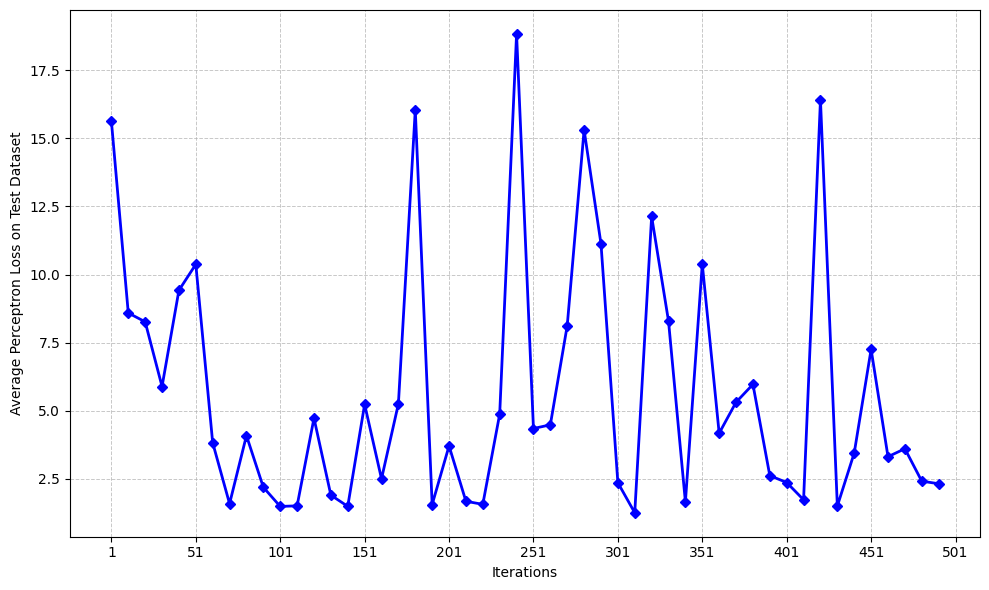

In [17]:
# PLOT THE TEST SET LOSS CURVE
plot_losses(test_losses, 'Iterations', 'Average Perceptron Loss on Test Dataset')

In [18]:
# GET THE MODEL PREDICTIONS ON THE TEST SET
preds = predict(x_test,w1)

print(f'TEST ACCURACY: {round(accuracy_score(y_test, preds)*100,2)}%')
print(f'TEST PRECISION: {round(precision_score(y_test, preds)*100,2)}%')
print(f'TEST RECALL: {round(recall_score(y_test, preds)*100,2)}%')
print(f'TEST F5: {round(fbeta_score(y_test, preds, beta=5)*100,2)}%')

TEST ACCURACY: 66.38%
TEST PRECISION: 100.0%
TEST RECALL: 2.5%
TEST F5: 2.6%


In [19]:
# OUTPUT THE WEIGHT VECTOR
w1

tensor([ 17.2176,  28.6196, -11.2279,  11.0434,   3.9991,  26.3373,  21.5611,
          9.6900], dtype=torch.float64)

POTENTIAL IMPROVEMENTS:-


~~1. Add L1 Regularization~~
2. MLP
3. Momentum, AdaGrad, RMSprop
~~4. Add bias term~~
5. Weight initialization


**LEARNING RATE SCHEDULING**

In [20]:
# LEARNING-RATE / STEP-SIZE
lr = 0.1

In [21]:
# WEIGHT VECTOR
# INITIALIZED TO ZERO
w2 = torch.zeros(x.shape[1], dtype=torch.float64)

In [22]:
test_losses = []

In [23]:
for j in range(n_iter):
    # VECTOR USED TO UPDATE THE WEIGHT VECTOR
    weight_update = torch.zeros_like(w2)

    for i in range(x_train.shape[0]):
        # INPUT VECTOR
        xi = x_train[i]
        # TARGET LABEL
        yi = y_train[i]
        # VALUE OF INDICATOR FUNCTION
        ind = indicator_func(xi,yi,w2)

        # ADD THE PERCEPTRON UPDATES FOR EACH ITERATION
        weight_update = weight_update + (yi*xi*ind)

    # UPDATE THE WEIGHT VECTOR
    w2 = w2 + lr*weight_update

    # EVERY 200 ITERATIONS REDUCE THE LEARNING-RATE BY A FACTOR OF 0.1
    if j%200 == 0:
        lr = lr*0.1

    if j%10 == 0:
        # CALCULATE THE PERCEPTRON LOSS ON THE TEST DATASET
        test_losses.append(loss_func(x_test,y_test,w2))

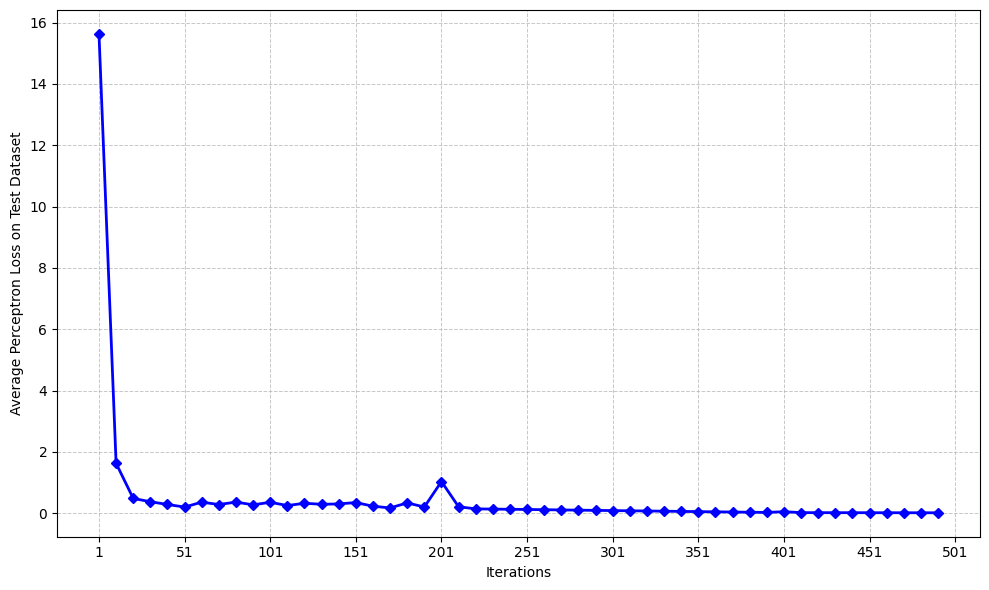

In [24]:
# PLOT THE TEST SET LOSS CURVE
plot_losses(test_losses, 'Iterations', 'Average Perceptron Loss on Test Dataset')

In [25]:
# GET THE MODEL PREDICTIONS ON THE TEST SET
preds = predict(x_test,w2)

print(f'TEST ACCURACY: {round(accuracy_score(y_test, preds)*100,2)}%')
print(f'TEST PRECISION: {round(precision_score(y_test, preds)*100,2)}%')
print(f'TEST RECALL: {round(recall_score(y_test, preds)*100,2)}%')
print(f'TEST F5: {round(fbeta_score(y_test, preds, beta=5)*100,2)}%')

TEST ACCURACY: 71.55%
TEST PRECISION: 59.46%
TEST RECALL: 55.0%
TEST F5: 55.16%


In [26]:
# OUTPUT THE WEIGHT VECTOR
w2

tensor([ 0.1000,  0.2446, -0.1494,  0.0133, -0.0970,  0.4345,  0.1154, -0.0042],
       dtype=torch.float64)

**L2 REGULARIZATION**

In [27]:
# LEARNING-RATE / STEP-SIZE
lr = 0.1

# L2 REGULARIZATION PARAMETER
l2_reg = 0.5

In [28]:
# WEIGHT VECTOR
# INITIALIZED TO ZERO
w3 = torch.zeros(x.shape[1], dtype=torch.float64)

In [29]:
test_losses = []

In [30]:
for j in range(n_iter):
    # VECTOR USED TO UPDATE THE WEIGHT VECTOR
    weight_update = torch.zeros_like(w3)

    for i in range(x_train.shape[0]):
        # INPUT VECTOR
        xi = x_train[i]
        # TARGET LABEL
        yi = y_train[i]
        # VALUE OF INDICATOR FUNCTION
        ind = indicator_func(xi,yi,w3)

        # ADD THE PERCEPTRON UPDATES FOR EACH ITERATION
        weight_update = weight_update + (yi*xi*ind)

    # UPDATE THE WEIGHT VECTOR
    w3 = w3 + lr*(weight_update - (l2_reg*w3))

    # EVERY 200 ITERATIONS REDUCE THE LEARNING-RATE BY A FACTOR OF 0.1
    if j%200 == 0:
        lr = lr*0.1

    if j%10 == 0:
        # CALCULATE THE PERCEPTRON LOSS ON THE TEST DATASET
        test_losses.append(loss_func(x_test,y_test,w3))

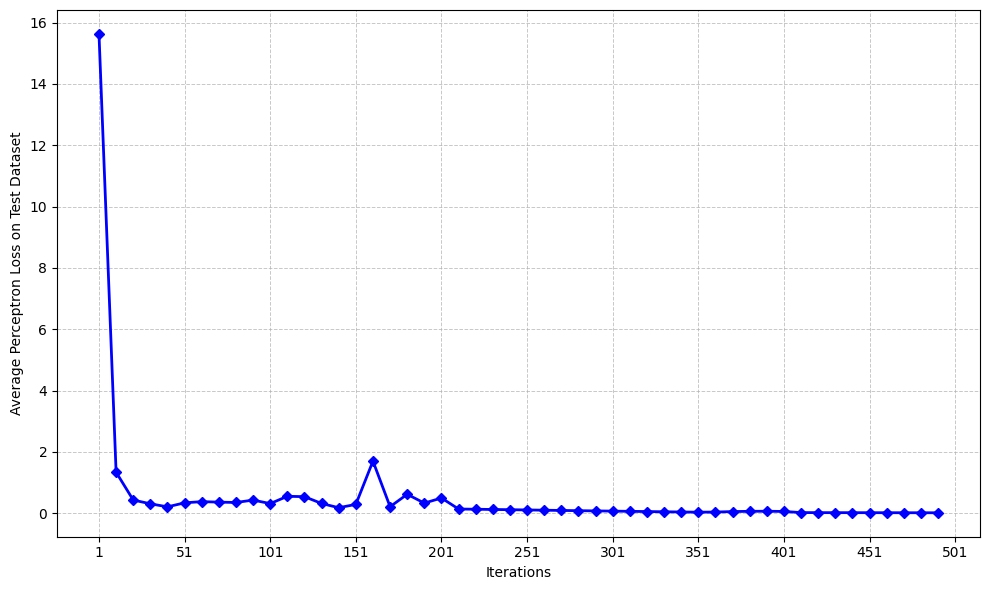

In [31]:
# PLOT THE TEST SET LOSS CURVE
plot_losses(test_losses, 'Iterations', 'Average Perceptron Loss on Test Dataset')

In [32]:
# GET THE MODEL PREDICTIONS ON THE TEST SET
preds = predict(x_test,w3)

print(f'TEST ACCURACY: {round(accuracy_score(y_test, preds)*100,2)}%')
print(f'TEST PRECISION: {round(precision_score(y_test, preds)*100,2)}%')
print(f'TEST RECALL: {round(recall_score(y_test, preds)*100,2)}%')
print(f'TEST F5: {round(fbeta_score(y_test, preds, beta=5)*100,2)}%')

TEST ACCURACY: 75.86%
TEST PRECISION: 65.79%
TEST RECALL: 62.5%
TEST F5: 62.62%


In [33]:
# OUTPUT THE WEIGHT VECTOR
w3

tensor([ 0.0718,  0.2025, -0.0990,  0.0098, -0.0723,  0.2737,  0.0927, -0.0032],
       dtype=torch.float64)

**ADDING BIAS**

In [34]:
# LEARNING-RATE / STEP-SIZE
lr = 0.1

In [35]:
# WEIGHT VECTOR INCLUDING BIAS
# INITIALIZED TO ZERO
w4 = torch.zeros(x.shape[1]+1, dtype=torch.float64)

In [36]:
test_losses = []

In [37]:
for j in range(n_iter):
    # VECTOR USED TO UPDATE THE WEIGHT VECTOR
    weight_update = torch.zeros_like(w4)

    for i in range(x_train.shape[0]):
        # INPUT VECTOR
        xi = torch.cat((x_train[i], torch.tensor([1.0])))
        # TARGET LABEL
        yi = y_train[i]
        # VALUE OF INDICATOR FUNCTION
        ind = indicator_func(xi,yi,w4)

        # ADD THE PERCEPTRON UPDATES FOR EACH ITERATION
        weight_update = weight_update + (yi*xi*ind)

    # UPDATE THE WEIGHT VECTOR
    w4 = w4 + lr*weight_update

    # EVERY 200 ITERATIONS REDUCE THE LEARNING-RATE BY A FACTOR OF 0.1
    if j%200 == 0:
        lr = lr*0.1

    if j%10 == 0:
        # CALCULATE THE PERCEPTRON LOSS ON THE TEST DATASET
        x_test_augmented = torch.cat((x_test, torch.ones(x_test.shape[0], 1)), dim=1)
        test_losses.append(loss_func(x_test_augmented,y_test,w4))

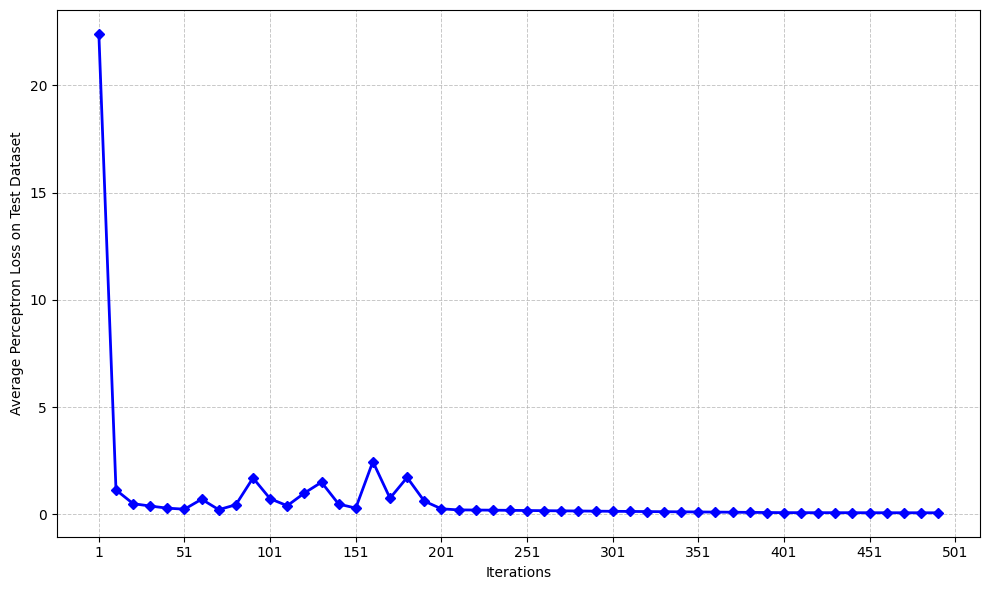

In [38]:
# PLOT THE TEST SET LOSS CURVE
plot_losses(test_losses, 'Iterations', 'Average Perceptron Loss on Test Dataset')

In [39]:
# GET THE MODEL PREDICTIONS ON THE TEST SET
preds = predict(x_test_augmented,w4)

print(f'TEST ACCURACY: {round(accuracy_score(y_test, preds)*100,2)}%')
print(f'TEST PRECISION: {round(precision_score(y_test, preds)*100,2)}%')
print(f'TEST RECALL: {round(recall_score(y_test, preds)*100,2)}%')
print(f'TEST F5: {round(fbeta_score(y_test, preds, beta=5)*100,2)}%')

TEST ACCURACY: 74.14%
TEST PRECISION: 63.16%
TEST RECALL: 60.0%
TEST F5: 60.12%


In [40]:
# OUTPUT THE WEIGHT VECTOR
w4

tensor([ 0.4132,  1.3278, -0.5053,  0.0481, -0.6675,  1.6596,  0.4320, -0.1967,
        -0.4154], dtype=torch.float64)

2. Meaning of - 'Providing examples illustrating its effects' - applications
5. Bibliography when citing a source in Latex document